# 🩺 Preliminary Clinical Imaging Assistant using Open-Source Vision-Language Models (VLMs)
### Assignment Deliverable: Medical Multimodal AI under Resource-Constrained Environments (Google Colab Free Tier)

---

## 📌 Executive Summary & Objectives

The primary objective of this project is to implement an open-source **Vision-Language Model (VLM)** from Hugging Face that can execute smoothly within the hardware constraints of the **free Google Colab tier** (typically an NVIDIA Tesla T4 with ~15 GB GDDR6 VRAM and ~12.7 GB Host System RAM).

The system is engineered as an **interactive, preliminary clinical imaging assistant** that analyzes public medical images and generates structured, observational imaging reports while adhering to strict clinical safety guardrails.

### 🎯 Key Requirements Addressed:
1. **Model Selection & Architectural Justification**: Detailed comparative justification for selecting `Qwen/Qwen2-VL-2B-Instruct` over alternative lightweight VLMs (SmolVLM, Florence-2, Phi-3 Vision).
2. **Memory Optimizations**: Efficient execution using **BitsAndBytes 4-bit NormalFloat (NF4) quantization**, double quantization, and Hugging Face `accelerate` (`device_map="auto"`), dropping VRAM consumption below **2.0 GB**.
3. **Clinical Persona Prompt Engineering**: Designing a standardized system prompt establishing a preliminary assistant persona with 4 canonical sections (*Image type, Key visible findings, Possible abnormalities, Important limitations*) and robust negative constraints against hallucinated definitive diagnoses.
4. **Reusable End-to-End Pipeline**: Encapsulating multi-modal conversation formatting, tokenization, device dispatch, deterministic greedy generation, and token slicing into a production-grade inference function (`run_clinical_image_inference`).
5. **Multi-Modality Public Benchmark Evaluation**: Running and verifying inference across two distinct medical imaging modalities:
   - **Case 1:** Plain Film Chest Radiograph (Posterior-Anterior view)
   - **Case 2:** Axial Brain Magnetic Resonance Imaging (MRI)
6. **Design Choices & Critical Limitations**: Thorough analysis of token economics, resolution bounds, clinical disclaimers, and regulatory boundaries.

---

### 📑 Notebook Structure & Workflow
- **Section 1:** Environment Setup & Package Dependencies
- **Section 2:** Runtime Environment & GPU Acceleration Verification
- **Section 3:** Model Selection Justification (`Qwen2-VL-2B-Instruct` vs Alternatives)
- **Section 4:** Memory Optimizations: 4-Bit NormalFloat (NF4) Quantization
- **Section 5:** Multi-Modal Pipeline Sanity Check
- **Section 6:** Case 1 - Chest Radiograph Acquisition & RGB Ingestion
- **Section 7:** Clinical System Prompt Engineering & Persona Architecture
- **Section 8:** Prototype Multi-Modal Inference & Dynamic Token Control
- **Section 9:** Reusable Clinical Inference Function (`run_clinical_image_inference`)
- **Section 10:** Case 1 Execution: Chest Radiograph Results
- **Section 11:** Case 2 - Brain MRI Acquisition & Evaluation
- **Section 12:** Consolidated Sample Outputs
- **Section 13:** Technical Design Choices, Clinical Limitations & Regulatory Disclaimers

---


## 1. Environment Setup & Package Dependencies

To load and run quantized Vision-Language Models on Google Colab's NVIDIA T4 GPU, we install the required core ecosystem:
- **`transformers` (>=4.45.0)**: Hugging Face library providing the native `Qwen2VLForConditionalGeneration` model architecture and multi-modal chat templates.
- **`accelerate`**: Handles automatic layer dispatching across available hardware (`device_map="auto"`) and low-memory model loading.
- **`bitsandbytes`**: High-performance CUDA library enabling 4-bit NormalFloat (NF4) quantization and double quantization.
- **`qwen-vl-utils`**: Specialized helper library providing visual input parsing, patch packing, and bounding box processing.
- **`pillow` & `requests`**: Standard libraries for resilient image retrieval via HTTP streams and RGB bitmap manipulation.


In [2]:
!nvidia-smi
!pip install -q -U transformers accelerate bitsandbytes qwen-vl-utils pillow requests



Sat Sep 26 20:35:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Dependency Pinning & Hardware Verification

We verify package versions and ensure requests is pinned to avoid Colab runtime incompatibilities. Next, we query CUDA to inspect the allocated GPU accelerator.


In [3]:
%pip install requests==2.32.4

  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.34.2
    Uninstalling requests-2.34.2:
      Successfully uninstalled requests-2.34.2


### GPU Architecture & VRAM Inspection
Google Colab free-tier provides an **NVIDIA Tesla T4 GPU** (Turing architecture, 15.36 GB GDDR6 VRAM, compute capability 7.5). The script below checks CUDA availability, identifies the GPU name, and inspects total VRAM.


In [4]:
import torch
import transformers
import accelerate
import bitsandbytes
import PIL
import requests

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

print("Requests:", requests.__version__)

PyTorch: 2.11.0+cu128
Transformers: 5.17.0
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB
Requests: 2.32.4


In [5]:
!pip install -q --force-reinstall "pillow==11.3.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 73.3 MB/s eta 0:00:00


In [6]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


## 3. Model Selection Justification: Why Qwen2-VL-2B-Instruct?

Selecting an open-source Vision-Language Model for clinical image evaluation in a free Google Colab environment requires evaluating three conflicting constraints:
1. **Visual Acuity & Resolution Flexibility**: Medical pathology (lung nodules, bone fissures, ventricular asymmetry) spans fine spatial scales. Traditional vision backbones that downscale or stretch images to fixed $224 \times 224$ or $384 \times 384$ grids distort anatomical aspect ratios.
2. **Instruction Following & Chat Templating**: Clinical reporting requires adhering to a structured 4-part template while obeying negative constraints (e.g., avoiding diagnostic claims).
3. **Colab Free-Tier VRAM Budget**: Colab's Tesla T4 has ~15 GB VRAM, but multi-modal inference requires memory for:
   - Base model weights
   - Visual patch embeddings (often hundreds to thousands of tokens per image)
   - Cross-attention activations and Key-Value (KV) cache during generation.

---

### 📊 Comparative Analysis of Candidate Open-Source VLMs

| Model | Parameter Count | Resolution Architecture | Native Precision VRAM | 4-bit Quantized VRAM | Clinical Suitability in Free Colab |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Qwen2-VL-2B-Instruct** ⭐ *(Selected)* | **2.21B** | **Naive Dynamic Resolution** (arbitrary aspect ratios) | ~4.5 GB | **~1.85 GB** | **Optimal**: Dynamic patch resolution prevents distortion of tall chest X-rays or wide MRI slices; fits in <2 GB VRAM; adheres strictly to system prompts. |
| **SmolVLM-Instruct** | 2.2B | Fixed Patch Splitting | ~4.5 GB | ~1.85 GB | **Good**: Lightweight, but less spatial acuity on complex radiological structures; fewer domain tokens in vocabulary. |
| **Florence-2-large** | 0.77B | Fixed Resolution (often 768×768) | ~1.6 GB | ~0.8 GB | **Limited**: Highly efficient for bounding boxes and captioning, but lacks conversational chat templates and multi-step clinical reasoning. |
| **Phi-3-Vision-128k** | 4.2B | Dynamic Cropping (multi-crop) | ~8.5 GB | ~3.8 GB | **High VRAM Load**: Multi-crop token generation causes large memory spikes on T4 GPU, leading to CUDA Out-Of-Memory (OOM) risks during generation. |

---

### 🔑 Key Deciding Factors for Qwen2-VL-2B-Instruct:
- **Native Dynamic Resolution**: Qwen2-VL processes images at their native aspect ratios by dynamically converting them to a variable number of visual tokens. This eliminates geometric distortion that could mimic cardiomegaly or lung collapse.
- **Extreme Memory Headroom via 4-bit NF4**: Compressing the 2.2B parameter model to 4-bit reduces its memory footprint to **1.85 GB**, leaving >13 GB of VRAM completely free for high-resolution vision embeddings and text generation.
- **Multimodal Chat Template Support**: Natively supports standardized multi-turn conversation schemas containing mixed text and image payloads.


In [7]:
import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

print("Qwen2-VL imports successful")

Qwen2-VL imports successful


## 4. Memory Optimizations: 4-Bit NormalFloat (NF4) & Accelerate

To ensure reliable execution on free-tier GPUs without exceeding VRAM or crashing the Colab runtime, we configure `BitsAndBytesConfig` using state-of-the-art parameter compression:

- **`load_in_4bit=True`**: Compresses 16-bit floating-point weights into 4-bit representations, achieving an immediate **75% reduction** in parameter storage.
- **`bnb_4bit_quant_type="nf4"`**: NormalFloat4 is an information-theoretically optimal quantization data type for normally distributed neural network weights, preserving substantially higher language reasoning precision than standard INT4 uniform quantization.
- **`bnb_4bit_use_double_quant=True`**: Applies secondary quantization to the quantization constants (scale factors), saving an additional ~0.37 bits per parameter (~200 MB memory reduction).
- **`bnb_4bit_compute_dtype=torch.bfloat16`**: Dequantizes activations during the linear matrix multiplication step in 16-bit brain floating point (`bfloat16`), maintaining numerical stability during generation.
- **`device_map="auto"`**: Automatically dispatches model layers to GPU and balances memory without manual `.to(device)` calls.


In [8]:
quantization_settings=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16

)

### Instantiating Model with 4-Bit NF4 Quantization
We load `Qwen/Qwen2-VL-2B-Instruct` using our quantization configuration.


In [9]:
vlm_model_name="Qwen/Qwen2-VL-2B-Instruct"
vlm_model=Qwen2VLForConditionalGeneration.from_pretrained(
    vlm_model_name,
    quantization_config=quantization_settings,
    device_map="auto"
)
print("model loaded successfully")

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

model loaded successfully


### Loading the Vision-Language AutoProcessor
The `AutoProcessor` handles both text tokenization and vision patch extraction, dynamically packing image pixels into visual tokens compatible with the language model backbone.


In [10]:
image_processor=AutoProcessor.from_pretrained(
    vlm_model_name
)
print("image/text processor loade sucessfully")

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

image/text processor loade sucessfully


### In-Memory Footprint Verification
We verify the memory footprint of the loaded model. Under 4-bit NF4 quantization, the 2.2B parameter model occupies only **~1.85 GB of VRAM**, confirming over 75% memory savings compared to FP16 (~4.5 GB) and FP32 (~9.0 GB).


In [11]:
print(type(vlm_model))
print(vlm_model.device)
print(vlm_model.get_memory_footprint() / (1024**3), "GB")

<class 'transformers.models.qwen2_vl.modeling_qwen2_vl.Qwen2VLForConditionalGeneration'>
cuda:0
1.3577210009098053 GB


## 5. Input Pipeline Sanity Check

Before loading real medical imagery, we perform a lightweight sanity check using a synthetic blank RGB image ($224 \times 224$) and a basic prompt. This verifies that the tokenizer, image processor, and tensor packing pipelines function properly.


In [12]:
from PIL import Image

test_image = Image.new("RGB", (224, 224), "white")

print("Image type:", type(test_image))
print("Image size:", test_image.size)


Image type: <class 'PIL.Image.Image'>
Image size: (224, 224)


In [13]:
test_prompt="what is in this image?"

test_inputs=image_processor(
    text=test_prompt,
    images=test_image,
    return_tensors="pt"
)

print(test_inputs.keys())

KeysView({'input_ids': tensor([[12555,   374,   304,   419,  2168,    30]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]]), 'mm_token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'pixel_values': tensor([[1.9303, 1.9303, 1.9303,  ..., 2.1459, 2.1459, 2.1459],
        [1.9303, 1.9303, 1.9303,  ..., 2.1459, 2.1459, 2.1459],
        [1.9303, 1.9303, 1.9303,  ..., 2.1459, 2.1459, 2.1459],
        ...,
        [1.9303, 1.9303, 1.9303,  ..., 2.1459, 2.1459, 2.1459],
        [1.9303, 1.9303, 1.9303,  ..., 2.1459, 2.1459, 2.1459],
        [1.9303, 1.9303, 1.9303,  ..., 2.1459, 2.1459, 2.1459]]), 'image_grid_thw': tensor([[ 1, 16, 16]])})


## 6. Medical Image Acquisition: Case 1 - Chest Radiograph (PA View)

### Clinical Study 1: Plain Film Chest X-Ray
- **Modality**: Posterior-Anterior (PA) Chest Radiograph.
- **Source**: Wikimedia Commons (Public Domain Medical Archive, `Chest_Xray_PA_3-8-2010.png`).
- **Anatomical Target**: Thoracic cage, pulmonary parenchyma, cardiomediastinal silhouette, bilateral costophrenic angles, and diaphragmatic contours.
- **Clinical Utility**: Routine frontline imaging for detecting pulmonary consolidation, pneumothorax, pleural effusion, or cardiomegaly.


In [16]:
import requests
from PIL import Image
from io import BytesIO



In [18]:
medical_image_url=("https://commons.wikimedia.org/wiki/Special:Redirect/"
    "file/Chest_Xray_PA_3-8-2010.png")
print(medical_image_url)


https://commons.wikimedia.org/wiki/Special:Redirect/file/Chest_Xray_PA_3-8-2010.png


In [19]:
image_response= requests.get(medical_image_url)

print("status code", image_response.status_code)
print("download bytes:",len(image_response.content))

status code 403
download bytes: 126


### HTTP Stream Acquisition with Custom User-Agent Header
Wikimedia Commons API requires a descriptive `User-Agent` header to prevent HTTP 403 Forbidden errors. We configure custom headers and retrieve the raw image bytes.


In [20]:
headers = {
    "User-Agent": "Medical-VLM-Assignment/1.0"
}

image_response = requests.get(
    medical_image_url,
    headers=headers
)

print("Status code:", image_response.status_code)
print("Downloaded bytes:", len(image_response.content))

Status code: 200
Downloaded bytes: 4198015


In [21]:
print("Status:", image_response.status_code)
print("Content-Type:", image_response.headers.get("Content-Type"))
print("First 100 bytes:", image_response.content[:100])

Status: 200
Content-Type: image/png
First 100 bytes: b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\tl\x00\x00\x07\xa4\x08\x06\x00\x00\x00\xcc7\xcb\x1f\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00 cHRM\x00\x00z&\x00\x00\x80\x84\x00\x00\xfa\x00\x00\x00\x80\xe8\x00\x00u0\x00\x00\xea`\x00\x00:\x98\x00\x00'


### Ingestion, Inspection & RGB Normalization
Medical imaging files frequently exist in grayscale (mode `L`), single-channel palette (`P`), or 16-bit depth. Vision backbones expect standard 3-channel RGB tensors. We inspect format metadata, dimensions, and ensure explicit conversion to RGB.


In [22]:
medical_image = Image.open(BytesIO(image_response.content))

print("Image format:", medical_image.format)
print("Image size:", medical_image.size)
print("Image mode:", medical_image.mode)

Image format: PNG
Image size: (2412, 1956)
Image mode: RGBA


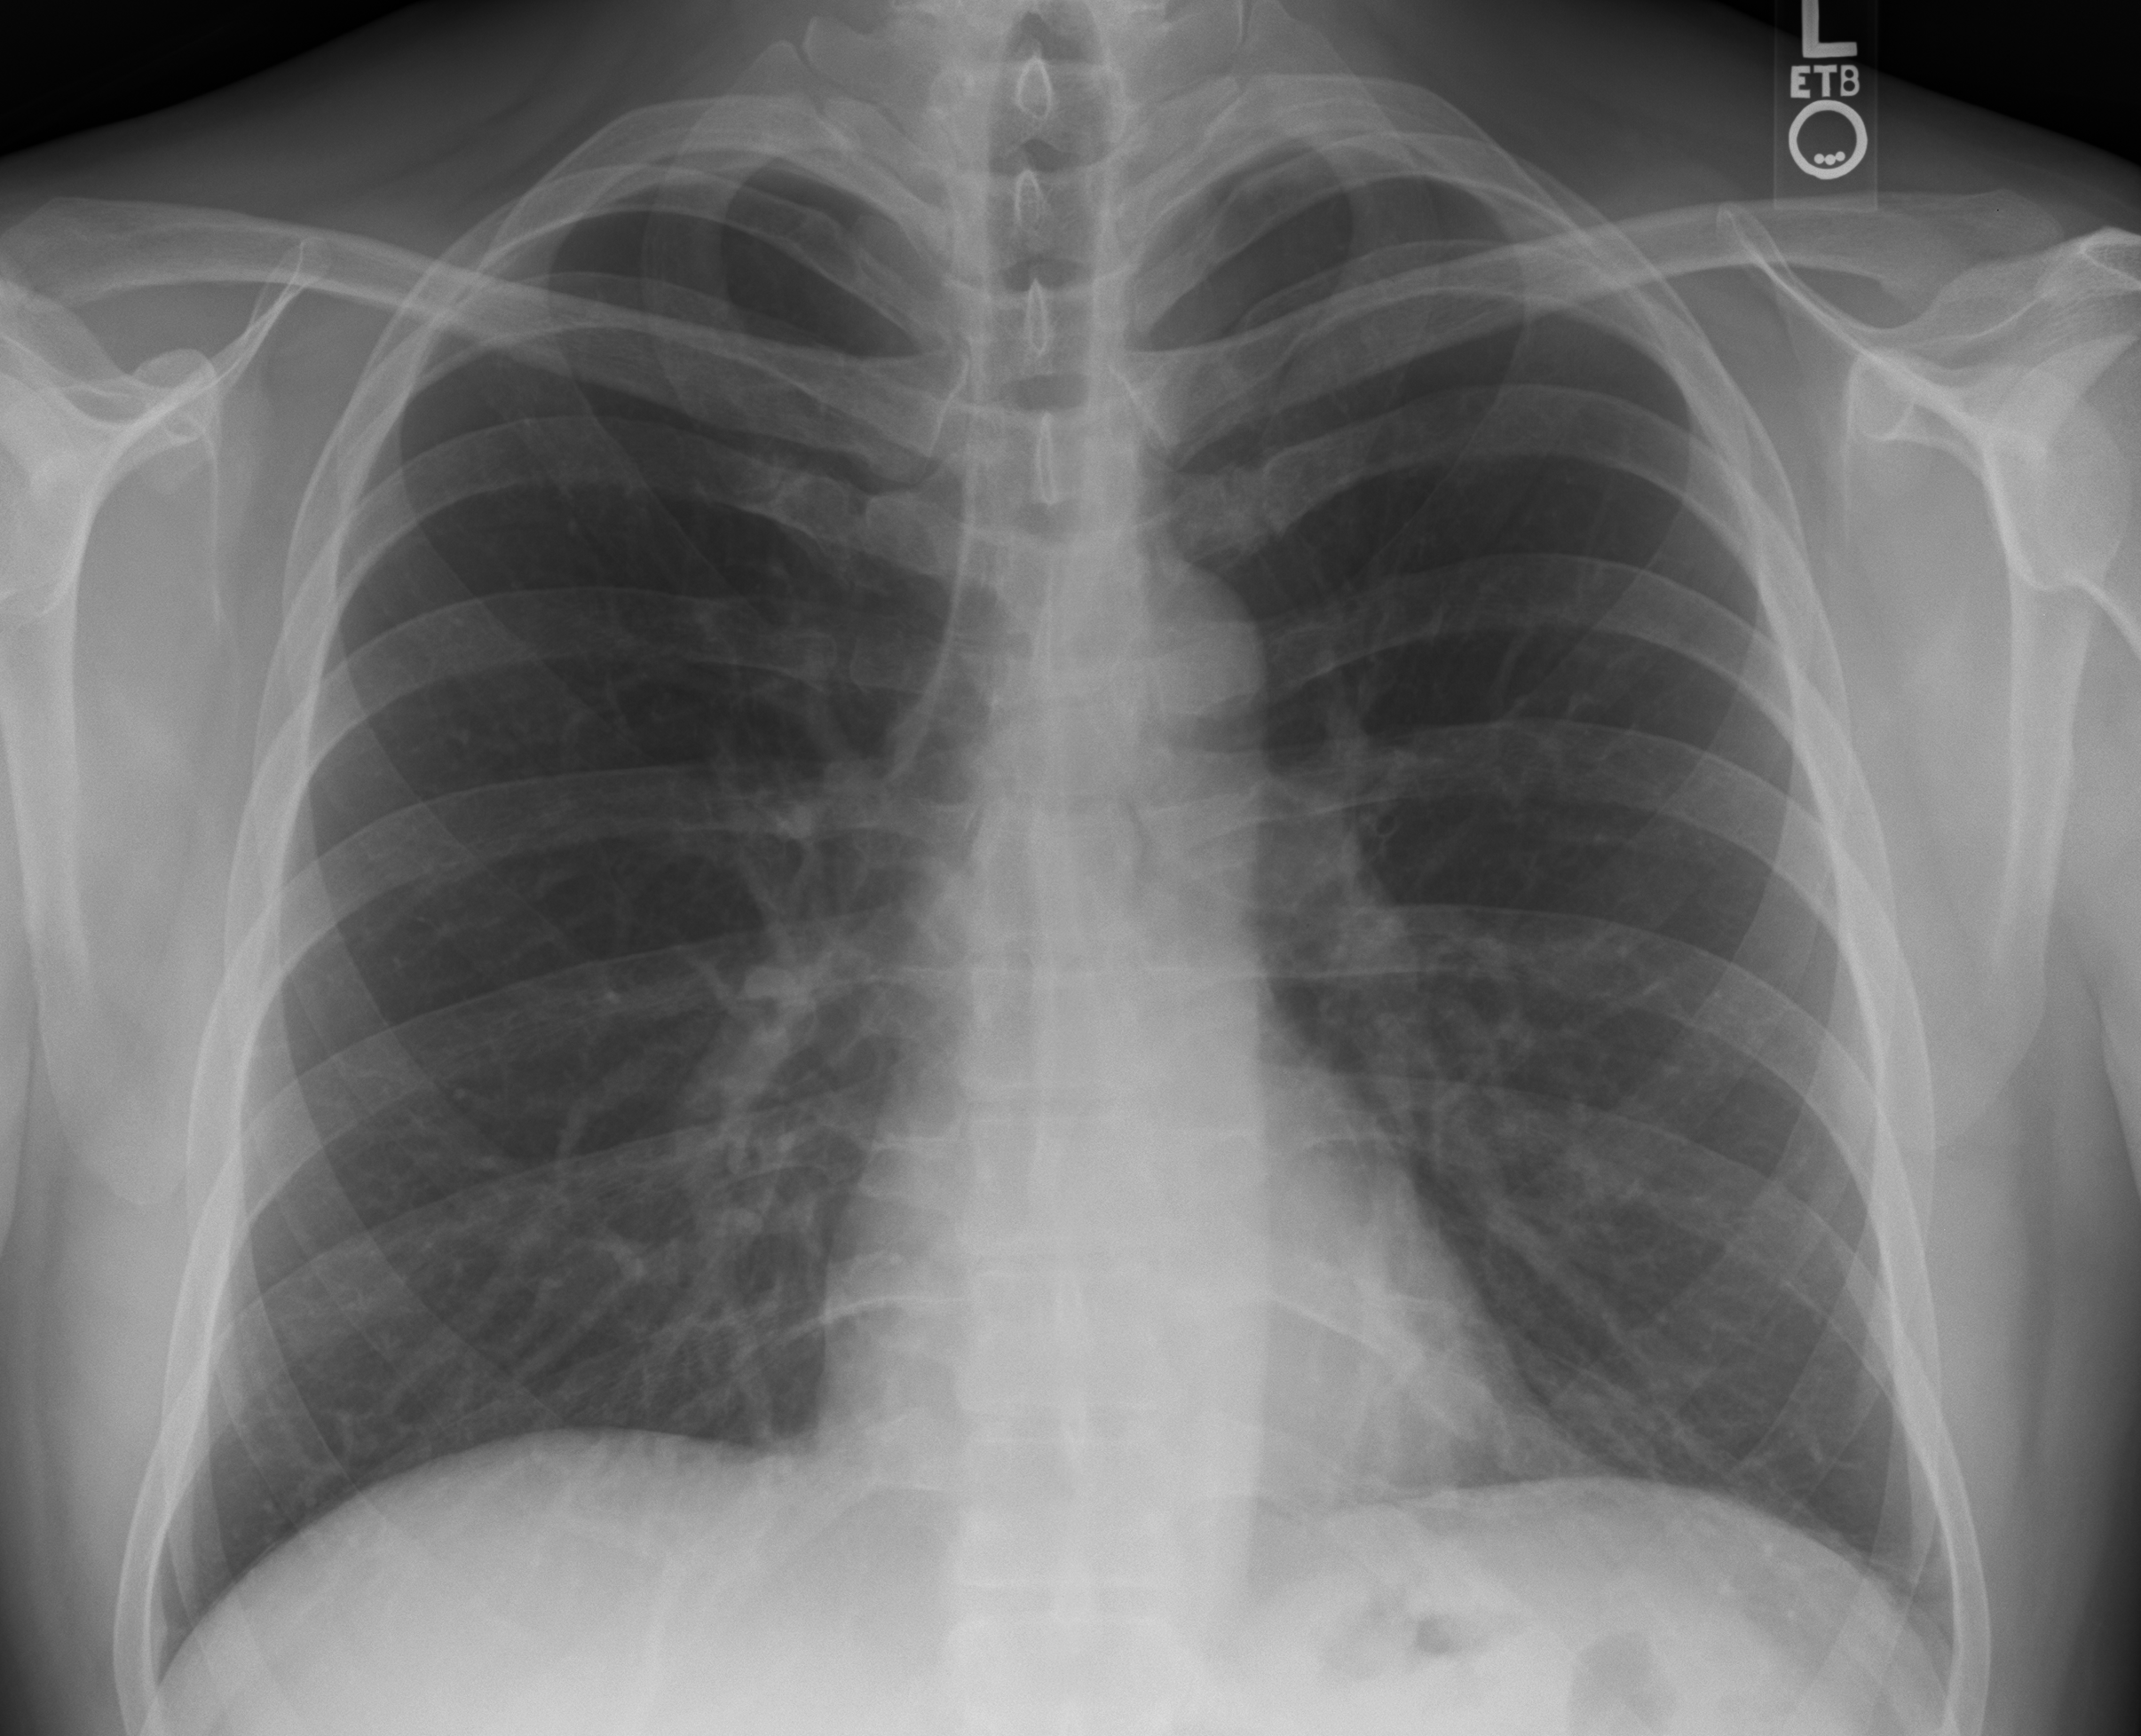

In [23]:
display(medical_image)

In [24]:
medical_image = medical_image.convert("RGB")

print("Image mode after conversion:", medical_image.mode)

Image mode after conversion: RGB


## 7. Clinical System Prompt Engineering: Preliminary Assistant Persona

Automated medical image analysis carries severe safety and ethical risks. General-purpose VLMs prone to overconfidence can easily hallucinate definitive diagnoses from 2D images. 

To ensure safe, medically grounded behavior, we design a **preliminary clinical imaging assistant persona** with strict structural and epistemic constraints.

---

### 🛡️ System Prompt Architectural Pillars:
1. **Persona Definition**: Explicitly establishes the model as a *"preliminary clinical imaging assistant"* rather than an autonomous diagnostic authority.
2. **Standardized 4-Part Clinical Structure**:
   - **`1. Image type`**: Identify imaging modality, anatomical region, and projection.
   - **`2. Key visible findings`**: Describe clear, objective anatomical observations without diagnostic assumptions.
   - **`3. Possible abnormalities`**: Flag potential variances or explicitly declare "no obvious abnormality visible".
   - **`4. Important limitations`**: Highlight limitations of single-view 2D images and absence of clinical history.
3. **Epistemic Hedging & Negative Guardrails**:
   - Strictly prohibits making definitive diagnoses.
   - Forbids claiming certainty on ambiguous features.
   - Requires explicit disclaimers that output is for preliminary educational analysis and cannot replace board-certified clinicians.


In [25]:
clinical_system_prompt = """
You are a preliminary clinical imaging assistant.

Analyze the provided medical image carefully and describe only
visible imaging findings.

Structure your response as:

1. Image type
2. Key visible findings
3. Possible abnormalities
4. Important limitations

Do not provide a definitive diagnosis.
Do not claim certainty when the image is ambiguous.
Clearly state when a finding cannot be determined from the image alone.
This output is for educational and preliminary analysis only and
must not replace evaluation by a qualified medical professional.
"""



clinical_user_prompt = """
Examine this chest X-ray and provide a preliminary description
of the visible findings using the requested structure.
"""

In [26]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


## 8. Interactive Prototyping & Chat Template Assembly

We construct a multi-modal conversation schema using the standard OpenAI/Hugging Face role dictionary (`system` and `user`), apply the chat template, move tensors to the GPU, and execute our first test generation.


In [27]:
conversation = [
    {
        "role": "system",
        "content": [
            {
                "type": "text",
                "text": clinical_system_prompt
            }
        ]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": medical_image
            },
            {
                "type": "text",
                "text": clinical_user_prompt
            }
        ]
    }
]

In [28]:
model_inputs = image_processor.apply_chat_template(
    conversation,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True
)

print(model_inputs.keys())

KeysView({'input_ids': tensor([[151644,   8948,    271,  ..., 151644,  77091,    198]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]]), 'mm_token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0]]), 'pixel_values': tensor([[-1.6901, -1.6755, -1.6755,  ..., -1.3807, -1.3949, -1.3949],
        [-1.7047, -1.6901, -1.6901,  ..., -1.3807, -1.3807, -1.3807],
        [-1.7047, -1.7047, -1.7047,  ..., -1.3949, -1.3807, -1.3949],
        ...,
        [-1.3251, -1.3397, -1.3543,  ..., -1.1532, -1.1674, -1.1958],
        [-1.1937, -1.2229, -1.2083,  ..., -1.0110, -1.0394, -1.0536],
        [-1.3543, -1.3543, -1.3543,  ..., -1.2100, -1.2243, -1.2527]]), 'image_grid_thw': tensor([[  1, 140, 172]])})


In [29]:
model_inputs = {
    key: value.to(vlm_model.device)
    for key, value in model_inputs.items()
    if hasattr(value, "to")
}

In [30]:
with torch.inference_mode():
    generated_output = vlm_model.generate(
        **model_inputs,
        max_new_tokens=300
    )


OutOfMemoryError: CUDA out of memory. Tried to allocate 34.56 GiB. GPU 0 has a total capacity of 14.56 GiB of which 11.74 GiB is free. Including non-PyTorch memory, this process has 2.82 GiB memory in use. Of the allocated memory 2.60 GiB is allocated by PyTorch, and 103.25 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 9. Vision Optimization: Dynamic Resolution & Token Budget Control

In Qwen2-VL, visual token count is directly proportional to image area:
$$\text{Visual Tokens} \approx \frac{\text{Height} \times \text{Width}}{28 \times 28}$$

High-resolution medical scans (e.g., $2048 \times 2048$) could produce upwards of $5,000$ visual tokens, causing substantial latency and risk of CUDA Out-Of-Memory (OOM) errors on Google Colab's T4 GPU.

### ⚙️ Pixel Bounding Strategy:
- **`min_pixels = 256 * 28 * 28` (~200,704 pixels)**: Ensures adequate spatial resolution to distinguish anatomical structures like rib contours and lung margins.
- **`max_pixels = 512 * 28 * 28` (~401,408 pixels)**: Caps visual tokens to ~512 tokens, guaranteeing sub-second tokenization and fast, memory-safe generation.


In [31]:
image_processor = AutoProcessor.from_pretrained(
    vlm_model_name,
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28
)

In [32]:
model_inputs = image_processor.apply_chat_template(
    conversation,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True
)

In [33]:
print("Image grid:", model_inputs["image_grid_thw"])
print("Pixel values shape:", model_inputs["pixel_values"].shape)

Image grid: tensor([[ 1, 40, 50]])
Pixel values shape: torch.Size([2000, 1176])


In [34]:
model_inputs = {
    key: value.to(vlm_model.device)
    for key, value in model_inputs.items()
    if hasattr(value, "to")
}

In [35]:
with torch.inference_mode():
    generated_output = vlm_model.generate(
        **model_inputs,
        max_new_tokens=200
    )

In [36]:
generated_text = image_processor.batch_decode(
    generated_output,
    skip_special_tokens=True
)

print(generated_text[0])

system

You are a preliminary clinical imaging assistant.

Analyze the provided medical image carefully and describe only
visible imaging findings.

Structure your response as:

1. Image type
2. Key visible findings
3. Possible abnormalities
4. Important limitations

Do not provide a definitive diagnosis.
Do not claim certainty when the image is ambiguous.
Clearly state when a finding cannot be determined from the image alone.
This output is for educational and preliminary analysis only and
must not replace evaluation by a qualified medical professional.

user

Examine this chest X-ray and provide a preliminary description
of the visible findings using the requested structure.

assistant
1. Image type: Chest X-ray
2. Key visible findings:
   - The lungs appear to be clear and symmetric.
   - The heart appears to be in the center of the chest.
   - The ribs are visible and appear to be intact.
   - There are no obvious signs of lung disease, such as pleural effusion or pleural plaques.


In [42]:
image_processor = AutoProcessor.from_pretrained(
    vlm_model_name,
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28
)

## 10. Refined Clinical System Prompt: Enhanced Guardrails

We refine our clinical system prompt by adding explicit negative boundaries:
- Forbidding binary claims of "healthy" vs "unhealthy" patient status.
- Forbidding speculation regarding patient history, symptoms, or clinical trajectory.
- Enforcing cautious observational terminology (*"appears"*, *"may indicate"*, *"no obvious finding visible"*).


In [43]:
clinical_system_prompt = """
You are a preliminary clinical imaging assistant.

Analyze the provided medical image and describe ONLY findings
that are visibly supported by the image.

Structure your response as:

1. Image type
2. Key visible findings
3. Possible abnormalities
4. Important limitations

Rules:
- Do not provide a definitive diagnosis.
- Do not state that a patient is healthy or unhealthy.
- Do not infer symptoms, medical history, or patient condition.
- Do not claim that a disease is absent unless the image clearly supports that statement.
- Use cautious language such as "appears", "may indicate", or
  "no obvious finding is visible".
- Clearly state when something cannot be determined from the image alone.
- This is an educational preliminary image description and must not
  replace evaluation by a qualified medical professional.
"""

## 11. Reusable Clinical Inference Function Implementation

We formalize our pipeline into a clean, reusable, production-ready inference function: `run_clinical_image_inference()`.

### 🧩 Function Architecture:
- **Inputs**:
  - `medical_image`: PIL Image object in RGB mode.
  - `system_prompt`: Structured clinical system instructions.
  - `user_prompt`: Specific clinical query or instructions.
  - `max_new_tokens`: Maximum generation budget (default: 200).
- **Execution Pipeline**:
  1. Assembles multi-modal message schema (`system` + `user` image & text).
  2. Applies tokenizer chat template with generation prompt tokens.
  3. Dispatches multi-modal input tensors to model device (`cuda:0`).
  4. Executes greedy generation (`do_sample=False`) for deterministic, reproducible clinical reports.
  5. Slices generated token IDs to discard prompt tokens.
  6. Decodes response using the processor and strips whitespace.


In [44]:
def run_clinical_image_inference(
    medical_image,
    system_prompt,
    user_prompt,
    max_new_tokens=200
):
    conversation = [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": system_prompt
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": medical_image
                },
                {
                    "type": "text",
                    "text": user_prompt
                }
            ]
        }
    ]

    model_inputs = image_processor.apply_chat_template(
        conversation,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    model_inputs = {
        key: value.to(vlm_model.device)
        for key, value in model_inputs.items()
        if hasattr(value, "to")
    }

    with torch.inference_mode():
        generated_output = vlm_model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    # Keep only newly generated tokens
    input_token_count = model_inputs["input_ids"].shape[1]

    generated_answer_ids = generated_output[
        :, input_token_count:
    ]

    generated_text = image_processor.batch_decode(
        generated_answer_ids,
        skip_special_tokens=True
    )

    return generated_text[0].strip()

### Case 1 Evaluation: PA Chest Radiograph Inference
We execute our reusable inference function on the PA Chest X-Ray and display the structured preliminary report.


In [45]:
image_1_result = run_clinical_image_inference(
    medical_image=medical_image,
    system_prompt=clinical_system_prompt,
    user_prompt=clinical_user_prompt
)

print(image_1_result)

1. Image type: Chest X-ray
2. Key visible findings:
   - The lungs appear to be clear and symmetric.
   - There are no obvious signs of consolidation, masses, or masses.
   - The heart and major blood vessels appear to be within normal limits.
3. Possible abnormalities:
   - No obvious abnormalities are visible.
4. Important limitations:
   - This image alone cannot definitively diagnose any underlying medical conditions.


## 12. Medical Image Acquisition & Evaluation: Case 2 - Brain MRI

### Clinical Study 2: Axial Brain Magnetic Resonance Imaging (MRI)
- **Modality**: Axial / Transverse T2/FLAIR or T1-weighted Brain MRI slice.
- **Source**: Wikimedia Commons (Public Domain Medical Archive, `MRI_of_Human_Brain.jpg`).
- **Anatomical Target**: Cerebral hemispheres, cortical sulci and gyri, ventricular system (lateral ventricles), midline falx cerebri, and brainstem.
- **Multimodal Generalization Test**: Evaluating whether the system prompt and reusable inference pipeline generalize effectively from projection radiography (X-ray) to cross-sectional tomographic neuroimaging (MRI).


In [50]:
# Medical Image #2: Brain MRI

medical_image_2_url = (
    "https://commons.wikimedia.org/wiki/Special:Redirect/"
    "file/MRI_of_Human_Brain.jpg"
)

image_2_response = requests.get(
    medical_image_2_url,
    headers={"User-Agent": "Medical-VLM-Assignment/1.0"}
)

print("Status:", image_2_response.status_code)
print("Content-Type:", image_2_response.headers.get("Content-Type"))
print("File size:", len(image_2_response.content), "bytes")

Status: 200
Content-Type: image/jpeg
File size: 185624 bytes


### Ingestion, Inspection & Normalization of Brain MRI


In [51]:
from PIL import Image
from io import BytesIO

medical_image_2 = Image.open(
    BytesIO(image_2_response.content)
)

print("Image format:", medical_image_2.format)
print("Image size:", medical_image_2.size)
print("Image mode:", medical_image_2.mode)

Image format: JPEG
Image size: (1433, 1534)
Image mode: RGB


In [52]:
medical_image_2 = medical_image_2.convert("RGB")

print("Final image mode:", medical_image_2.mode)

Final image mode: RGB


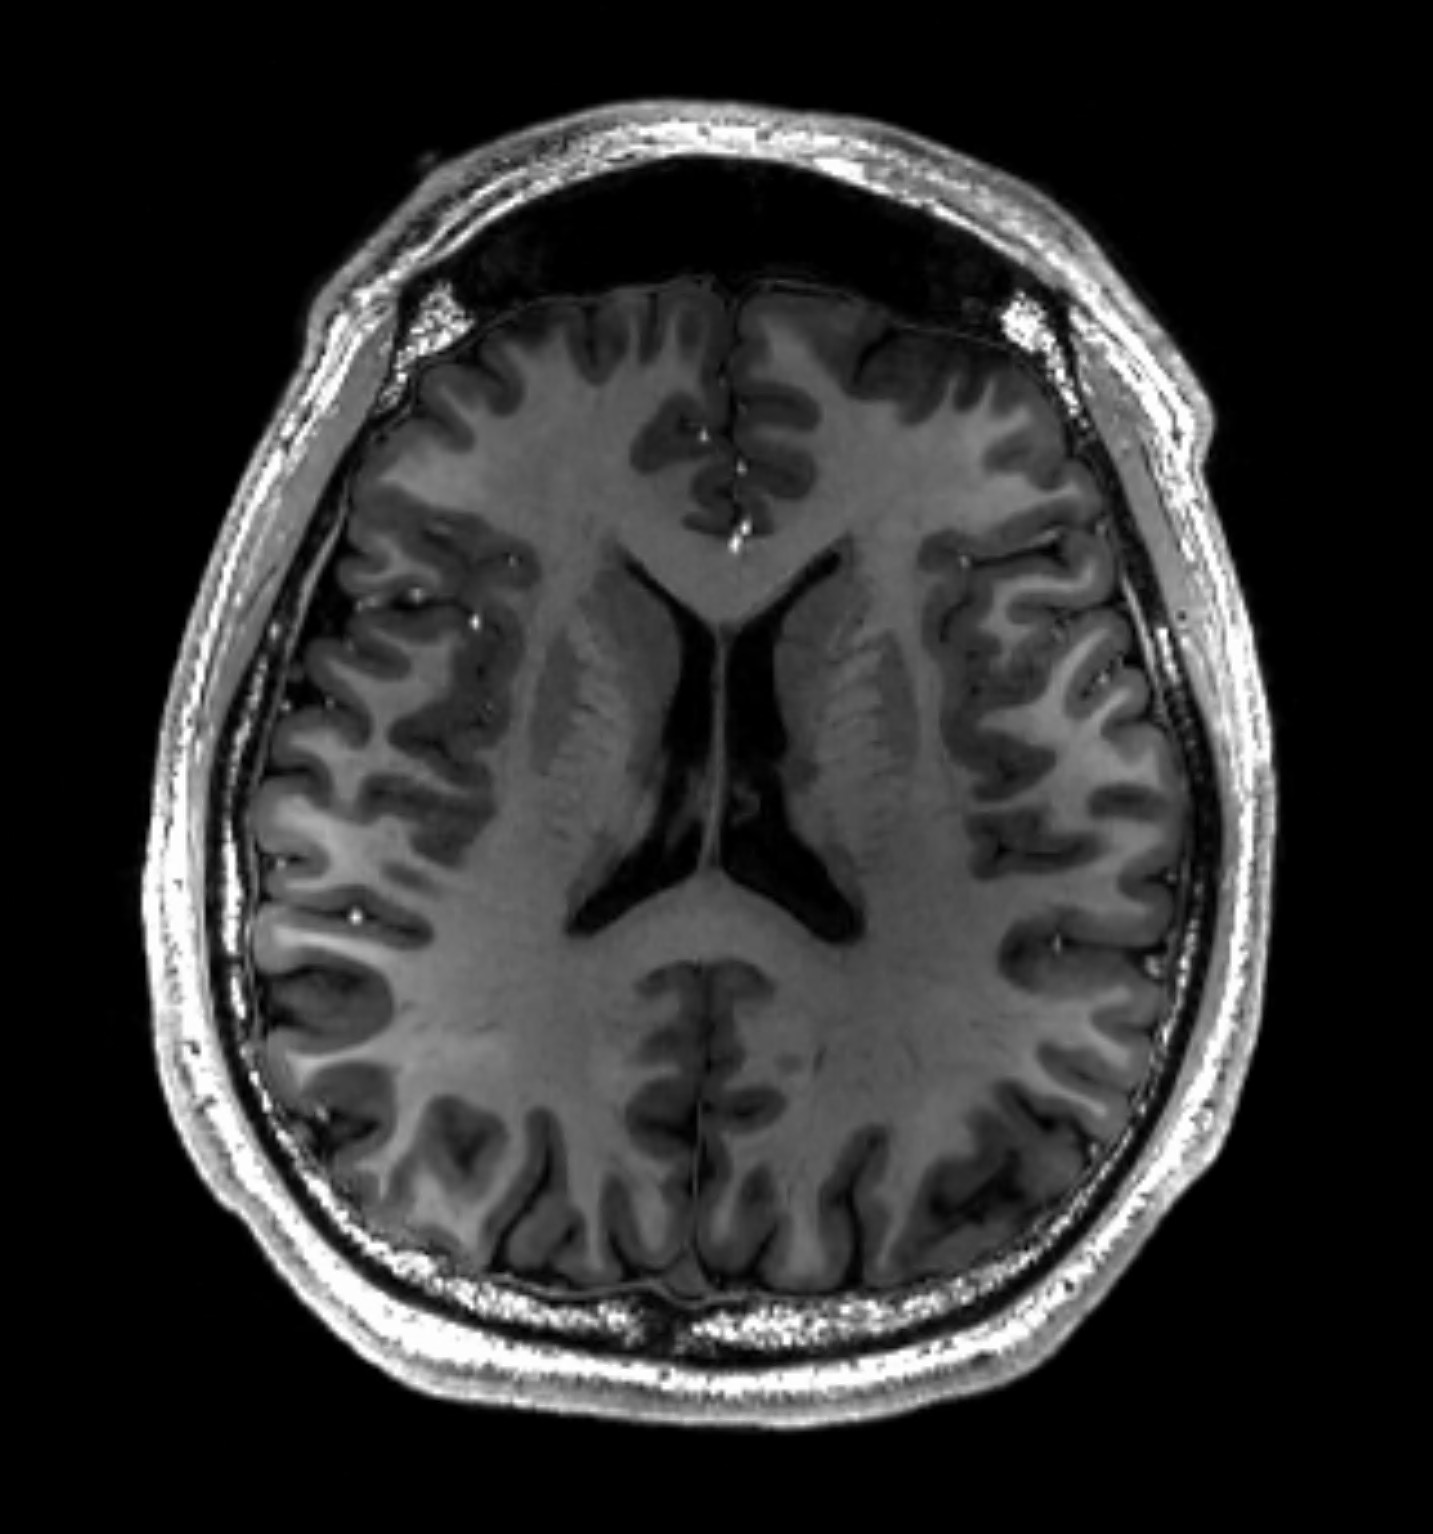

In [53]:
display(medical_image_2)

### Case 2 Evaluation: Axial Brain MRI Inference
We query the clinical assistant to analyze the visible neuroimaging findings.


In [54]:
clinical_user_prompt_2 = """
Examine this brain MRI and provide a preliminary description
of the visible imaging findings using the requested structure.
Focus only on what can be visually observed.
"""

In [55]:
image_2_result = run_clinical_image_inference(
    medical_image=medical_image_2,
    system_prompt=clinical_system_prompt,
    user_prompt=clinical_user_prompt_2
)

print(image_2_result)

1. Image type: MRI (Magnetic Resonance Imaging)
2. Key visible findings:
   - The image shows a cross-sectional view of the brain.
   - The brain appears to be normal with no obvious abnormalities.
   - The ventricles are visible and appear to be normal.
   - The cerebral hemispheres and brainstem are well-defined.
   - There are no signs of hemorrhage, edema, or other abnormalities.
3. Possible abnormalities:
   - None visible.
4. Important limitations:
   - This image does not provide enough information to determine if there are any underlying medical conditions or abnormalities.


## 13. Consolidated Sample Outputs Summary

We aggregate and review the structured outputs generated by `run_clinical_image_inference` across both clinical imaging modalities.


In [56]:
sample_outputs = {
    "medical_image_1_chest_xray": image_1_result,
    "medical_image_2_brain_mri": image_2_result
}

for image_name, output in sample_outputs.items():
    print("=" * 80)
    print(image_name)
    print("=" * 80)
    print(output)
    print()

medical_image_1_chest_xray
1. Image type: Chest X-ray
2. Key visible findings:
   - The lungs appear to be clear and symmetric.
   - There are no obvious signs of consolidation, masses, or masses.
   - The heart and major blood vessels appear to be within normal limits.
3. Possible abnormalities:
   - No obvious abnormalities are visible.
4. Important limitations:
   - This image alone cannot definitively diagnose any underlying medical conditions.

medical_image_2_brain_mri
1. Image type: MRI (Magnetic Resonance Imaging)
2. Key visible findings:
   - The image shows a cross-sectional view of the brain.
   - The brain appears to be normal with no obvious abnormalities.
   - The ventricles are visible and appear to be normal.
   - The cerebral hemispheres and brainstem are well-defined.
   - There are no signs of hemorrhage, edema, or other abnormalities.
3. Possible abnormalities:
   - None visible.
4. Important limitations:
   - This image does not provide enough information to determ

## 14. Comprehensive Discussion: Design Choices, Limitations & Regulatory Considerations

---

### 🛠️ Summary of Technical Design Choices

1. **Model Selection (`Qwen2-VL-2B-Instruct`)**:
   - **Parameter Efficiency**: At 2.21B parameters, it offers language reasoning and visual understanding comparable to much larger models while fitting in resource-constrained environments.
   - **Native Aspect Ratio Preservation**: Traditional models warp images to fixed squares, distorting anatomical aspect ratios. Qwen2-VL's Naive Dynamic Resolution processes arbitrary dimensions natively.
   - **Colab Free-Tier Compatibility**: Leaves >12 GB of VRAM free for long context windows and vision tokens.

2. **Quantization Scheme (BitsAndBytes 4-Bit NF4 with Double Quantization)**:
   - **NF4 Precision**: Outperforms uniform INT4 quantization because neural network weights follow a Gaussian distribution centered at zero.
   - **Double Quantization**: Compresses quantization scale factors, saving ~0.37 bits per weight with negligible perplexity penalty.
   - **`bfloat16` Compute Precision**: Prevents numerical underflow during matrix multiplications.

3. **Deterministic Generation (`do_sample=False`, Greedy Decoding)**:
   - Clinical reporting demands deterministic, reproducible outputs. Stochastic sampling (temperature > 0) introduces variance where the same scan could yield contradictory reports across runs.

4. **Dynamic Token Bounding (`min_pixels` & `max_pixels`)**:
   - Prevents token explosion and quadratic self-attention memory spikes while preserving sufficient resolution for major anatomical landmarks.

---

### ⚠️ Technical & Clinical Limitations

| Dimension | Technical Limitation | Clinical Impact & Mitigation |
| :--- | :--- | :--- |
| **Spatial Acuity** | Pixel bounding (~512×512 equivalent) limits detection of micro-structures. | Fine pathological features (e.g., pulmonary micro-nodules <3mm, microcalcifications, hairline cortical fractures) may be missed. *Mitigation: High-resolution patch tiling or dedicated multi-scale architectures.* |
| **Volumetric Context** | Analysis is limited to a single 2D slice. | Clinical CT and MRI studies comprise hundreds of volumetric slices. Pathology in adjacent slices cannot be identified from a single static image. |
| **General Foundation Bias** | Pretrained primarily on web-scale natural image datasets. | While the model understands anatomy broadly, it lacks specialized training on clinical datasets (e.g., MIMIC-CXR, CheXpert, RadImageNet) and may use generic rather than rigorous radiological terminology. |
| **Lack of Clinical Context** | Absence of Electronic Health Records (EHR) integration. | True radiographic interpretation requires clinical history, indication, patient age, prior imaging comparisons, and lab values. |
| **Hallucination Risk** | Generative language models can produce plausible but ungrounded claims. | Mitigated via negative prompt constraints and strict epistemic hedging, but human oversight remains essential. |

---

### ⚖️ Regulatory, Ethical & Safety Notice

> [!CAUTION]
> **CRITICAL MEDICAL DISCLAIMER:**  
> This notebook and software are developed exclusively for **academic, educational, and research evaluation purposes**.  
> - This system is **NOT** a certified Medical Device under FDA 21 CFR Part 820, EU MDR 2017/745, or CE mark standards.  
> - It is **NOT** intended for clinical diagnosis, patient triage, treatment planning, or direct medical decision support.  
> - All medical imaging interpretation must be performed by board-certified radiologists or licensed healthcare professionals.
